In [ ]:
import sys
# Use an absolute path or relative path to the directory
sys.path.append("scripts")

import numpy as np
import pdb_voxelizier
import cnn_mlp_encoder
import jw_quantum_mapper
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
from scipy.linalg import eigh
import sympy
import openfermion as op
import pyvista as pv
import torch
import cirq

In [96]:
num_sites = 6
tensor = pdb_voxelizier.pdb_to_tensor('proteins/1ENH.pdb')
coefficients = cnn_mlp_encoder.get_hamiltonian(tensor, num_qubits=num_sites)
qubit_instructions = jw_quantum_mapper.apply_jw(coefficients,num_sites=num_sites)

# qubit_instructions

In [97]:
def visualize_tensor(tensor):
    # [batch_size, channels, Depth, Height, Width]
    protein = tensor[0]
    
    protein = protein.to_dense().max(axis=0).values

    array = protein.numpy()
    grid = pv.wrap(array) # Automatically recognizes as a dataset
    grid.plot(jupyter_backend="client",volume=True)

torch_tensor = torch.from_numpy(tensor)
visualize_tensor(torch_tensor)

Widget(value='<iframe src="http://localhost:46619/index.html?ui=P_0x7fd4cd702fd0_5&reconnect=auto" class="pyvi…

Test our hamiltonian through a VQE!

In [98]:
# To convert our list of strings into a PauliSum, we need to loop through each instruction
def convert_qubit_operators_to_paulisum(qubit_operators:list):
    complete_pauli_string = op.QubitOperator()
    for i in qubit_operators:
  
        # Split up the operation into coefficient and the gates
        operation_list = i.split("*")
        
        # We grab the coefficient as a float and each operator as a single string   
        coef = float(operation_list[0])
        operators = operation_list[1].strip()

        # We construct qubit operators using OpenFermion
        complete_pauli_string += op.QubitOperator(operators,coef)
        
        # Convert string coefficient into float
        coef = float(operation_list[0])
    
    # Convert those qubit operators directly into a paulisum
    complete_pauli_string = op.qubit_operator_to_pauli_sum(complete_pauli_string)
    
    return complete_pauli_string

pauli_string = convert_qubit_operators_to_paulisum(qubit_instructions)

Get the ground state energy classically

In [99]:
# Now, we need to get the ground state energy using OpenFermion

# First, we need to convert our coefficients into a matrix that can be processed by OpenFermion
# We can define a hamiltonian (hermitian) matrix using the condensed 1D coefficient matrix:
#  - The first 'num_sites' values map to individual site energies, which can be the diagonal values of the hermitian matrix
site_energies = coefficients[:num_sites]
print(f"Site energies: {site_energies}") 
# - The rest of the values are hopping integrals, and can be used to define the upper triangular of the hermitian matrix
#   (Which also defines the lower triangular, as hermitian matrices are symmetric)
hopping_integrals = coefficients[num_sites:]
print(f"Hopping integrals: {hopping_integrals}")

# To define the matrix, we use scipy.spatial.distance's squareform to get a Hermitian matrix
hamiltonian_matrix = squareform(hopping_integrals)

# From here, we fill the diagonals with site energies

np.fill_diagonal(hamiltonian_matrix,site_energies)
print("\nFinal Hamiltonian Matrix:")
print(hamiltonian_matrix)

# Now, we use numpy.linalg.eigh to calculate the ground state value of this matrix
lowest = min(eigh(hamiltonian_matrix)[0])
# lowest = op.get_ground_state(hamiltonian_matrix)[0]

print(f"\nGround State Energy: {lowest}")


Site energies: [-0.0389608  -0.10307271 -0.11131632 -0.07183589  0.03353276 -0.00327195]
Hopping integrals: [-0.08139183  0.05780214 -0.03509345 -0.00264707 -0.07535719  0.00603934
 -0.02532537 -0.05167134  0.02798469  0.04640267 -0.08716847  0.07971431
 -0.09271551 -0.01507333  0.03431918]

Final Hamiltonian Matrix:
[[-0.0389608  -0.08139183  0.05780214 -0.03509345 -0.00264707 -0.07535719]
 [-0.08139183 -0.10307271  0.00603934 -0.02532537 -0.05167134  0.02798469]
 [ 0.05780214  0.00603934 -0.11131632  0.04640267 -0.08716847  0.07971431]
 [-0.03509345 -0.02532537  0.04640267 -0.07183589 -0.09271551 -0.01507333]
 [-0.00264707 -0.05167134 -0.08716847 -0.09271551  0.03353276  0.03431918]
 [-0.07535719  0.02798469  0.07971431 -0.01507333  0.03431918 -0.00327195]]

Ground State Energy: -0.23876839876174927


Estimate ground state energy using VQE

In [108]:
# Now, lets create our ansatz circuit. In this case I use a variation of the hardware efficient Ansatz (HEA) from the Lab 9 Knapsack problem example
# -----------------------------
# Parameterized circuit (ansatz)
# -----------------------------
qubits = list(pauli_string.qubits)
n = len(qubits)
layers = 3
symbols = sympy.symbols(f'theta(0:{n*layers})')
circuit = cirq.Circuit()

def create_HAE_ansatz(circuit,layers:int,qubit_count:int):
    for l in range(layers):  # 3 layers
        for i in range(qubit_count):
            circuit.append(cirq.rx(symbols[l * n + i])(qubits[i]))
        for i in range(qubit_count - 1):
            circuit.append(cirq.CZ(qubits[i], qubits[i + 1]))
    print(circuit)
    return circuit
circuit = create_HAE_ansatz(circuit,layers=layers,qubit_count=n)

def create_UCCSD_ansatz():
    pass
# Also taken from Lab 9 Knapsack problem example

# -----------------------------
# Expectation function
# -----------------------------

def expectation(params):
    resolver = cirq.ParamResolver({str(symbols[i]): params[i] for i in range(len(symbols))})
    result = simulator.simulate(circuit, resolver);

    # "i" for indice, "q" for qubit
    var = pauli_string.expectation_from_state_vector(
        result.final_state_vector,
        qubit_map={q: i for i, q in enumerate(qubits)}
    ).real
    # print(var)
    return var


0: ───Rx(theta0)───@───Rx(theta6)────────────────@────────────Rx(theta12)─────────────────@─────────────────────────────────────────────────
                   │                             │                                        │
1: ───Rx(theta1)───@───@────────────Rx(theta7)───@────────────@─────────────Rx(theta13)───@─────────────@───────────────────────────────────
                       │                                      │                                         │
2: ───Rx(theta2)───────@────────────@────────────Rx(theta8)───@─────────────@─────────────Rx(theta14)───@─────────────@─────────────────────
                                    │                                       │                                         │
3: ───Rx(theta3)────────────────────@────────────@────────────Rx(theta9)────@─────────────@─────────────Rx(theta15)───@─────────────@───────
                                                 │                                        │                           

Now we can run our circuit and attempt to converge on the ground state energy of the PauliSum.
There are a few optimizers we can choose from:
Type of solver. Should be one of:
    'Nelder-Mead'
    'Powell' 
    'CG' 
    'BFGS' 
    'Newton-CG' 
    'L-BFGS-B' 
    'TNC' 
    'COBYLA' 
    'COBYQA' 
    'SLSQP' 
    'trust-constr'
    'dogleg' 
    'trust-ncg' 
    'trust-exact' 
    'trust-krylov' 

In [ ]:
# -----------------------------
# VQE Optimization
# -----------------------------
simulator = cirq.Simulator()

# Random Angles calculated here!
x0 = np.random.uniform(0, 2 * np.pi, len(symbols))

res = minimize(expectation, x0=x0, method='COBYLA', options={'maxiter': 1000})

print("Optimal parameters:", res.x)
print("Minimum energy estimate:", res.fun)

# Now that we have our optimal parameters and minimum energy estimate, we run the circuit with those parameters to verify the output
resolver = cirq.ParamResolver({str(symbols[i]): res.x[i] for i in range(len(symbols))})
sample = simulator.simulate(circuit, resolver)

result = pauli_string.expectation_from_state_vector(
    sample.final_state_vector,
    qubit_map={q: i for i, q in enumerate(qubits)}
).real

print(f"The ground state energy from quantum circuit: {result}")
print(f"The ground state energy from diagnalization: {lowest}")

# Visualize accuracy correlated to the number of sites simulated/the number of qubits used.
# One plot for each protein.

Optimal parameters: [ 3.56532483  5.54987254  7.11596242  2.56649464  1.73197769  1.91892401
  6.12864433  3.63516865  1.74426634  6.7957082   6.94292051  3.80065509
  1.28616351  4.10023119  4.76477757  4.62299886  4.87187869  1.44943551
  3.34012632  3.43543869  0.85466294  1.05221775 -0.23078103  1.4941969
  1.82314648  5.99341456  3.15479398  1.0644365   4.36960126  2.61796804
  2.11453118  5.93009623  4.97587405  4.73753223  0.0512603  -0.15964916]
Minimum energy estimate: -0.31398423194754865
The ground state energy from quantum circuit: -0.31398423194754865
The ground state energy from diagnalization: -0.23876839876174927


In [112]:
# Now, lets calculate the average 
# This loop runs through 10 variations of the circuit with 1-10 layers applied to see how the depth of the circuit affects the output
# WARNING: Each VQE in each loop runs 15 times for 1000 iterations (15 * 1000 = 15,000 iterations!). Will be a little heavy on the cpu
loop_results = []
loops = 10
for i in range(loops):
    print(i)
    qubits = list(pauli_string.qubits)
    n = len(qubits)
    layers = i + 1
    symbols = sympy.symbols(f'theta(0:{n*layers})')
    circuit = cirq.Circuit()

    def create_HAE_ansatz(circuit,layers:int,qubit_count:int):
        for l in range(layers):  # 3 layers
            for i in range(qubit_count):
                circuit.append(cirq.rx(symbols[l * n + i])(qubits[i]))
            for i in range(qubit_count - 1):
                circuit.append(cirq.CZ(qubits[i], qubits[i + 1]))
        return circuit
    circuit = create_HAE_ansatz(circuit,layers,n)

    def create_UCCSD_ansatz():
        pass
    # Also taken from Lab 9 Knapsack problem example

    # -----------------------------
    # Expectation function
    # -----------------------------

    def expectation(params):
        resolver = cirq.ParamResolver({str(symbols[i]): params[i] for i in range(len(symbols))})
        result = simulator.simulate(circuit, resolver);

        # "i" for indice, "q" for qubit
        var = pauli_string.expectation_from_state_vector(
            result.final_state_vector,
            qubit_map={q: i for i, q in enumerate(qubits)}
        ).real
        # print(var)
        return var

    # -----------------------------
    # VQE Optimization
    # -----------------------------
    simulator = cirq.Simulator()

    iterations = 15
    result_total = 0.0

    for j in range(iterations):
        # Random Angles calculated here!
        x0 = np.random.uniform(0, 2 * np.pi, len(symbols))

        res = minimize(expectation, x0=x0, method='COBYLA', options={'maxiter': 100})

        # print("Optimal parameters:", res.x)
        # print("Minimum energy estimate:", res.fun)

        # Now that we have our optimal parameters and minimum energy estimate, we run the circuit with those parameters to verify the output
        resolver = cirq.ParamResolver({str(symbols[i]): res.x[i] for i in range(len(symbols))})
        sample = simulator.simulate(circuit, resolver)

        result = pauli_string.expectation_from_state_vector(
            sample.final_state_vector,
            qubit_map={q: i for i, q in enumerate(qubits)}
        ).real

        # print(i)

        result_total += abs(100 * ((result-lowest)/((lowest+result)/2)))
        # result_list.append(result)
        # print(f"The ground state energy from quantum circuit: {result}")
        # print(f"The ground state energy from diagnalization: {lowest}")

    loop_results.append(result_total / iterations)
    # print(f"In {iterations} runs, at 1000 iterations each, the average difference between the quantum simulation GSE and the actual GSE was: {result_total}")
    
    # print(result_list)
    # print(lowest)

for i in range(len(loop_results)):
    loop_results[i] = round(loop_results[i],2)



0
1
2
3
4
5
6
7
8
9


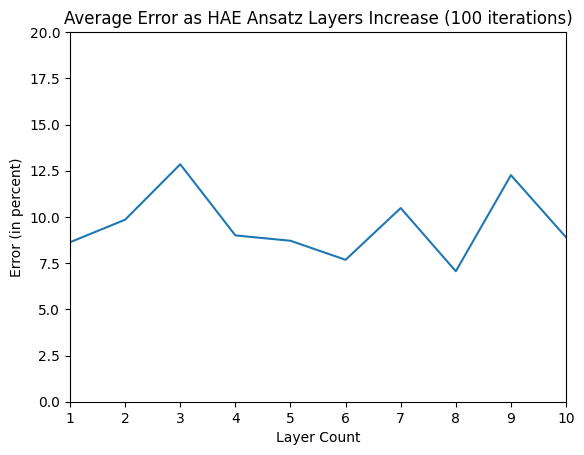

In [ ]:
# Now, we can plot our values!
# Consider using this or a stacked-bar chart
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.set_ylim(top=20)
ax.set_xlim(1,right=10)
ax.set_title("Average Error")
ax.set_ylabel("Error (in percent)\n(1000 iterations)")
ax.set_xlabel("Hardware-Efficient Ansatz Layer Count")

ax.plot([x+1 for x in range(10)],loop_results)
fig.savefig("old_plot")
plt.show()